# **Step 1: Mount Google Drive, Set paths to read and drop files and install required libraries**

In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.5 MB/s eta 0:00:00


In [ ]:
# --------------------------------------------------------
# Importing all required Libraries
# --------------------------------------------------------

# OS & File Management
import os
import zipfile
import random
from pathlib import Path
from collections import defaultdict
import time

# Data Handling
import pandas as pd
import numpy as np

# Medical Imaging
import pydicom
from pydicom import dcmread
from pydicom.pixels import apply_voi_lut
from pydicom.pixel_data_handlers.util import apply_voi_lut

# Computer Vision
import cv2
from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Gaussian Process Regression
from scipy import stats
from numpy.linalg import inv
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# ------------------------------------------
# 📦 SETUP: RSNA Lumbar Spine Classification data from GDrive
# ------------------------------------------

# Google Colab
from google.colab import drive
drive.mount('/content/drive')
# -----------------------
# ZIP AND PATH SETUP
# -----------------------
CUSTOM_DRIVE_ADDRESS = "custom/folder"

ZIP_PATH = f"/content/drive/My Drive/{CUSTOM_DRIVE_ADDRESS}/rsna-2024-lumbar-spine-degenerative-classification.zip"
CSV_EXTRACT_DIR = f"/content/drive/My Drive/{CUSTOM_DRIVE_ADDRESS}/rsna_spine_data"
TRAIN_IMG_ROOT = "/content/train_images"
TEST_IMG_ROOT = "/content/test_images"

# -----------------------
# EXTRACT CSV FILES TO DRIVE
# -----------------------
if not os.path.exists(CSV_EXTRACT_DIR):
    os.makedirs(CSV_EXTRACT_DIR, exist_ok=True)
    !unzip -j "{ZIP_PATH}" '*.csv' -d "{CSV_EXTRACT_DIR}"
    print("CSV files extracted to Drive.")
else:
    print("CSV files already extracted.")

# -----------------------
# EXTRACT DICOMs TO COLAB RAM (preserving folder structure)
# -----------------------
if not os.path.exists(TRAIN_IMG_ROOT):
    !unzip -q "{ZIP_PATH}" 'train_images/*' -d "/content/"
    print("Train DICOMs extracted to Colab RAM with structure preserved.")
else:
    print("Train DICOMs already extracted to Colab RAM.")

if not os.path.exists(TEST_IMG_ROOT):
    !unzip -q "{ZIP_PATH}" 'test_images/*' -d "/content/"
    print("Test DICOMs extracted to Colab RAM with structure preserved.")
else:
    print("Test DICOMs already extracted to Colab RAM.")

# -----------------------
# LOAD CSV FILES
# -----------------------
LABEL_CSV_PATH = os.path.join(CSV_EXTRACT_DIR, "train_label_coordinates.csv")
STUDY_LABELS_PATH = os.path.join(CSV_EXTRACT_DIR, "train.csv")
SERIES_META_PATH = os.path.join(CSV_EXTRACT_DIR, "train_series_descriptions.csv")
TEST_SERIES_META_PATH = os.path.join(CSV_EXTRACT_DIR, "test_series_descriptions.csv")
SUBMISSION_PATH = os.path.join(CSV_EXTRACT_DIR, "sample_submission.csv")

df_labels = pd.read_csv(LABEL_CSV_PATH)
df_study_labels = pd.read_csv(STUDY_LABELS_PATH)
df_series_meta = pd.read_csv(SERIES_META_PATH)
df_test_series_meta = pd.read_csv(TEST_SERIES_META_PATH)
df_sample_submission = pd.read_csv(SUBMISSION_PATH)

# -----------------------
# Map Series Description into Labels (Prep Only – full merge later)
# -----------------------
series_desc_map = df_series_meta.set_index(['study_id', 'series_id'])['series_description'].to_dict()
# We’ll merge this into df_labels later once df_labels is cleaned/formatted.

# -----------------------
# STATUS
# -----------------------
print("DataFrames loaded:")
print(f"→ df_labels               : {df_labels.shape}")
print(f"→ df_study_labels         : {df_study_labels.shape}")
print(f"→ df_series_meta          : {df_series_meta.shape}")
print(f"→ df_test_series_meta     : {df_test_series_meta.shape}")
print(f"→ df_sample_submission    : {df_sample_submission.shape}")

print("DICOM paths:")
print(f"→ TRAIN_IMG_ROOT          : {TRAIN_IMG_ROOT}")
print(f"→ TEST_IMG_ROOT           : {TEST_IMG_ROOT}")

print("Unique train series descriptions:")
print(df_series_meta['series_description'].nunique(), "types")
print(df_series_meta['series_description'].value_counts())


Mounted at /content/drive
CSV files already extracted.
Train DICOMs extracted to Colab RAM with structure preserved.
Test DICOMs extracted to Colab RAM with structure preserved.
DataFrames loaded:
→ df_labels               : (48692, 7)
→ df_study_labels         : (1975, 26)
→ df_series_meta          : (6294, 3)
→ df_test_series_meta     : (3, 3)
→ df_sample_submission    : (25, 4)
DICOM paths:
→ TRAIN_IMG_ROOT          : /content/train_images
→ TEST_IMG_ROOT           : /content/test_images
Unique train series descriptions:
3 types
series_description
Axial T2            2340
Sagittal T1         1980
Sagittal T2/STIR    1974
Name: count, dtype: int64


In [ ]:
# -----------------------------------------------
# Final Unified df_labels with condition_level format (with class_id = 0 if not affected)
# -----------------------------------------------

def normalize(text):
    return text.lower().replace(" ", "_").replace("/", "_")

# Step 1: Create Image_ID
df_labels["Image_ID"] = df_labels.apply(
    lambda row: f"{row['study_id']}_{row['series_id']}_{int(row['instance_number'])}", axis=1
)

# Step 2: Create normalized condition_level (NOT level_condition)
df_labels["condition_level"] = df_labels.apply(
    lambda row: f"{normalize(row['condition'])}_{normalize(row['level'])}", axis=1
)

# Step 3: Pull series_description from df_series_meta
series_desc_map = df_series_meta.set_index(['study_id', 'series_id'])['series_description'].to_dict()
df_labels["series_description"] = df_labels.set_index(["study_id", "series_id"]).index.map(series_desc_map)

# Step 4: Pull severity from df_study_labels (train.csv)
df_study_labels.index = df_study_labels.index.astype(str)
df_labels["study_id"] = df_labels["study_id"].astype(str)

# Normalize columns
df_labels["condition_level"] = df_labels["condition_level"].apply(normalize)
df_study_labels.columns = [normalize(col) for col in df_study_labels.columns]

# Set study_id as index for lookup
if df_study_labels.index.name != "study_id":
    df_study_labels.set_index("study_id", inplace=True)

df_study_labels.index = df_study_labels.index.astype(str)

# Lookup severity label
def get_severity(row):
    try:
        return df_study_labels.loc[row["study_id"], row["condition_level"]]
    except KeyError:
        return None

df_labels["severity_label"] = df_labels.apply(get_severity, axis=1)

# Step 5: Map severity to numeric
severity_map = {"Normal/Mild": 0, "Moderate": 1, "Severe": 2}
df_labels["severity_code"] = df_labels["severity_label"].map(severity_map)

# Step 6: Map condition_level to index
# Step 6: Map condition_level to index starting from 1
condition_level_list = list(df_study_labels.columns)
condition_level_to_index = {k: i + 1 for i, k in enumerate(condition_level_list)}  # Start from 1

df_labels["condition_level_index"] = df_labels["condition_level"].map(condition_level_to_index)

# Step 7: Final class_id
# severity_code in [1, 2] → assign class_id = 1–25
# severity_code == 0 → assign class_id = 0 (background)
df_labels["class_id"] = df_labels.apply(
    lambda row: row["condition_level_index"] if row["severity_code"] in [1, 2] else 0, axis=1
)


# Final preview
print("Fully enriched df_labels with corrected naming and `class_id = 0` for Normal/Mild.")
display(df_labels[[
    "Image_ID", "study_id", "series_id", "instance_number",
    "condition", "level", "condition_level",
    "series_description", "severity_label", "severity_code", "class_id"
]].head())

# Store enriched dataset
training_data_combined = df_labels


Fully enriched df_labels with corrected naming and `class_id = 0` for Normal/Mild.


,Image_ID,study_id,series_id,instance_number,condition,level,condition_level,series_description,severity_label,severity_code,class_id
0,4003253_702807833_8,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,spinal_canal_stenosis_l1_l2,Sagittal T2/STIR,Normal/Mild,0.0,0
1,4003253_702807833_8,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,spinal_canal_stenosis_l2_l3,Sagittal T2/STIR,Normal/Mild,0.0,0
2,4003253_702807833_8,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,spinal_canal_stenosis_l3_l4,Sagittal T2/STIR,Normal/Mild,0.0,0
3,4003253_702807833_8,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,spinal_canal_stenosis_l4_l5,Sagittal T2/STIR,Normal/Mild,0.0,0
4,4003253_702807833_8,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,spinal_canal_stenosis_l5_s1,Sagittal T2/STIR,Normal/Mild,0.0,0


**Create Class_id**

In [ ]:
# --------------------------------------------------------
# Setup mappings for condition-level
# --------------------------------------------------------

# Step 1: Reverse the condition_level_to_index map
index_to_condition_level = {v: k for k, v in condition_level_to_index.items()}

# Step 2: Extract unique condition and level IDs from condition_level
unique_condition_ids = sorted(set(k.rsplit("_", 2)[0] for k in condition_level_to_index.keys()))
unique_level_ids = sorted(set("_".join(k.rsplit("_", 2)[1:]) for k in condition_level_to_index.keys()))

# Step 3: Optional numeric mappings (for encoding if needed)
condition_id_to_num = {cond: i for i, cond in enumerate(unique_condition_ids)}
level_id_to_num = {lvl: i for i, lvl in enumerate(unique_level_ids)}

# Step 4: Updated decode_class_id (skip -1 and unknowns)
def decode_class_id(class_id):
    if class_id == 0:
        return {"condition_id": None, "level_id": None}

    key = index_to_condition_level.get(class_id)
    if key is None:
        return {"condition_id": None, "level_id": None}

    condition_id = key.rsplit("_", 2)[0]
    level_id = "_".join(key.rsplit("_", 2)[1:])
    return {
        "condition_id": condition_id,
        "level_id": level_id
    }

print("Class ID decoder is ready. Use decode_class_id(class_id) for mapping.")


Class ID decoder is ready. Use decode_class_id(class_id) for mapping.


# Check a sample for generated severity code and class_id

In [ ]:
# Replace with actual values to be checked
study_id_check = "4646740"
condition_level_check = "spinal_canal_stenosis_l3_l4"

# Filter rows from df_labels
df_subset = df_labels[
    (df_labels["study_id"] == str(study_id_check)) &
    (df_labels["condition_level"] == condition_level_check)
]

# Show unique severity labels and codes
if not df_subset.empty:
    print(f"From df_labels for study_id = {study_id_check}, condition_level = {condition_level_check}:")
    print("Unique severity_label values:", df_subset["severity_label"].unique())
    print("Unique severity_code values:", df_subset["severity_code"].unique())
    display(df_subset[[
        "Image_ID", "severity_label", "severity_code", "class_id"
    ]].head())
else:
    print("No matching rows found in df_labels for this study_id and condition_level.")


From df_labels for study_id = 4646740, condition_level = spinal_canal_stenosis_l3_l4:
Unique severity_label values: ['Moderate']
Unique severity_code values: [1.]


,Image_ID,severity_label,severity_code,class_id
45,4646740_3666319702_9,Moderate,1.0,3


**Visualize DICOMs from Train & Test folders**

Train DICOM: /content/train_images/1670838975/4004350093/36.dcm
Metadata → study_id: 1670838975, series_id: 4004350093, instance_number: 36


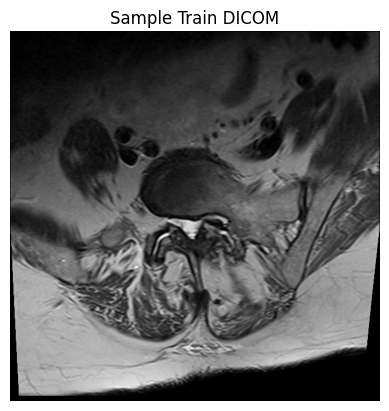

Test DICOM: /content/test_images/44036939/3481971518/40.dcm
Metadata → study_id: 44036939, series_id: 3481971518, instance_number: 40


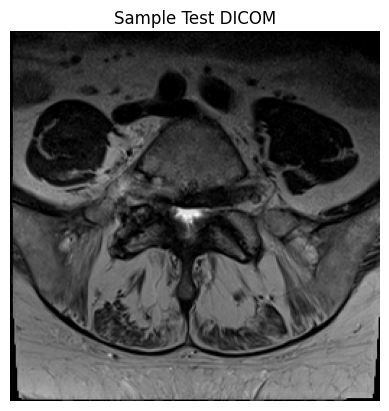

In [ ]:
# -----------------------------
# Helper: Load & show DICOM
# -----------------------------
def show_dicom_image(dcm_path, title="DICOM Image"):
    ds = pydicom.dcmread(dcm_path)
    image = apply_voi_lut(ds.pixel_array, ds)
    image = image.astype("float32")

    # Normalize to 0–1 for display
    image = (image - image.min()) / (image.max() - image.min())

    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# -----------------------------
# Helper: Extract metadata from path
# -----------------------------
def parse_dicom_path(dcm_path):
    parts = Path(dcm_path).parts
    study_id = parts[-3]
    series_id = parts[-2]
    instance_number = parts[-1].replace(".dcm", "")
    return study_id, series_id, instance_number

# -----------------------------
# Load one TRAIN image
# -----------------------------
train_root = Path("/content/train_images")
random_train_study = random.choice(os.listdir(train_root))
random_train_series = random.choice(os.listdir(train_root / random_train_study))
random_train_dcm = random.choice(os.listdir(train_root / random_train_study / random_train_series))

train_dcm_path = train_root / random_train_study / random_train_series / random_train_dcm
train_study_id, train_series_id, train_instance = parse_dicom_path(train_dcm_path)

print(f"Train DICOM: {train_dcm_path}")
print(f"Metadata → study_id: {train_study_id}, series_id: {train_series_id}, instance_number: {train_instance}")
show_dicom_image(train_dcm_path, title="Sample Train DICOM")

# -----------------------------
# Load one TEST image
# -----------------------------
test_root = Path("/content/test_images")
random_test_study = random.choice(os.listdir(test_root))
random_test_series = random.choice(os.listdir(test_root / random_test_study))
random_test_dcm = random.choice(os.listdir(test_root / random_test_study / random_test_series))

test_dcm_path = test_root / random_test_study / random_test_series / random_test_dcm
test_study_id, test_series_id, test_instance = parse_dicom_path(test_dcm_path)

print(f"Test DICOM: {test_dcm_path}")
print(f"Metadata → study_id: {test_study_id}, series_id: {test_series_id}, instance_number: {test_instance}")
show_dicom_image(test_dcm_path, title="Sample Test DICOM")


# **check the meta data:**
This meta data has Instance Number, which is mapped against the instance number of train_label_coordinates.csv to put the X and Y coordinate to point the main part of the image.

In [ ]:
# -------------------------------------------------
# DICOM Metadata Viewer
# -------------------------------------------------
# Replace with any path from your dataset
dcm_path = "/content/train_images/4003253/702807833/1.dcm"  # ⬅️ Update if needed

try:
    ds = pydicom.dcmread(dcm_path)

    print("DICOM file loaded successfully.\n")

    # Print full DICOM header (all tags)
    print("🔍 Full Metadata Dump:")
    print("=" * 50)
    print(ds)

    # Optional: Print some common fields directly
    print("\n Key Metadata Fields:")
    print(f"→ Patient ID           : {ds.get('PatientID', 'N/A')}")
    print(f"→ Study Instance UID   : {ds.get('StudyInstanceUID', 'N/A')}")
    print(f"→ Series Description   : {ds.get('SeriesDescription', 'N/A')}")
    print(f"→ Instance Number      : {ds.get('InstanceNumber', 'N/A')}")
    print(f"→ Modality             : {ds.get('Modality', 'N/A')}")
    print(f"→ Image Size           : {ds.Rows} x {ds.Columns}")

except Exception as e:
    print(f"Failed to load DICOM: {e}")


DICOM file loaded successfully.

🔍 Full Metadata Dump:
Dataset.file_meta -------------------------------
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Enhanced MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 4003253.1.1
(0002,0010) Transfer Syntax UID                 UI: RLE Lossless
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002,0013) Implementation Version Name         SH: 'PYDICOM 2.4.2'
-------------------------------------------------
(0008,0018) SOP Instance UID                    UI: 4003253.1.1
(0008,0023) Content Date                        DA: '20240503'
(0008,0033) Content Time                        TM: '223718.007977'
(0008,103E) Series Description                  LO: 'T2'
(0010,0020) Patient ID                          LO: '4003253'
(0018,0050) Slice Thickness                     DS: '4.0'
(0018,0088) Spacing Between Slices              DS: '4.8'
(0018,

**Load DICOM by Instance Number & Show Target Coordinate**

Found DICOM slice for instance 8: /content/train_images/4003253/702807833/8.dcm


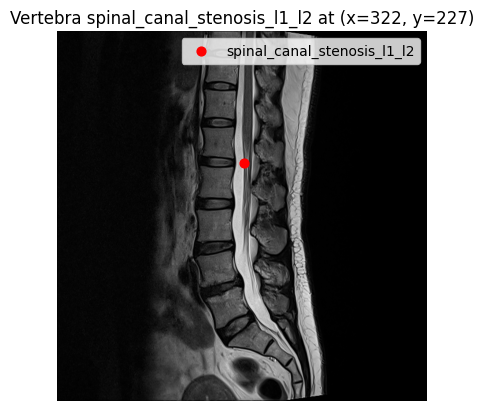

In [ ]:
# -----------------------
# Get DICOM Path by Instance Number
# -----------------------
def get_dcm_path_by_instance(folder, target_instance_number):
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            ds = pydicom.dcmread(fpath, stop_before_pixels=True)
            if hasattr(ds, "InstanceNumber") and ds.InstanceNumber == target_instance_number:
                return fpath
        except:
            continue
    return None

# -----------------------
# Target identifiers (sample row from training_data_combined)
# -----------------------
sample_row = training_data_combined.iloc[0]
study_id = sample_row["study_id"]
series_id = sample_row["series_id"]
target_instance_number = sample_row["instance_number"]
target_label = sample_row["condition_level"]
x, y = sample_row["x"], sample_row["y"]

# -----------------------
# Locate and load DICOM
# -----------------------
folder_path = f"/content/train_images/{study_id}/{series_id}"
dcm_path = get_dcm_path_by_instance(folder_path, target_instance_number)

if dcm_path:
    print(f"Found DICOM slice for instance {target_instance_number}: {dcm_path}")

    ds = pydicom.dcmread(dcm_path)
    image = apply_voi_lut(ds.pixel_array, ds).astype("float32")
    image = (image - image.min()) / (image.max() - image.min())

    # -----------------------
    # Plot image with marker
    # -----------------------
    plt.imshow(image, cmap='gray')
    plt.scatter(x, y, c='red', s=40, label=target_label)
    plt.title(f"Vertebra {target_label} at (x={int(x)}, y={int(y)})")
    plt.legend()
    plt.axis('off')
    plt.show()

else:
    print(" Could not find DICOM with that instance number.")


**Step3 : Crate a balanced sample with 25 classes while keeping train and val datasets disjoint**

In [ ]:
# --------------------------------------------------
# Stratified Sampling with 25 class and one Background Class
# --------------------------------------------------

# Step 1: Create binary affected flag
df_labels["affected"] = (df_labels["severity_code"] > 0).astype(int)

# Step 2: Sampling constants
N_TOTAL_TRAIN = 5000
N_TOTAL_VAL = 500

N_TRAIN_BG = int(0.20 * N_TOTAL_TRAIN)  # 40% → background class (-1)
N_TRAIN_AFFECTED = N_TOTAL_TRAIN - N_TRAIN_BG  # 60% → affected classes

N_VAL_BG = int(0.20 * N_TOTAL_VAL)
N_VAL_AFFECTED = N_TOTAL_VAL - N_VAL_BG

# Step 3: Train sample – class_id == 0, stratified by condition_level_index
df_bg = df_labels[df_labels["class_id"] == 0]
N_PER_LEVEL_BG = N_TRAIN_BG // df_bg["condition_level_index"].nunique()

df_train_bg = (
    df_bg
    .groupby("condition_level_index")
    .apply(lambda x: x.sample(n=min(N_PER_LEVEL_BG, len(x)), random_state=42))
    .reset_index(drop=True)
)

# Step 4: Train sample – affected class_id ∈ [0, 24]
df_affected = df_labels[df_labels["affected"] == 1]
N_PER_CLASS_AFFECTED = N_TRAIN_AFFECTED // df_affected["class_id"].nunique()

df_train_affected = (
    df_affected
    .groupby("class_id")
    .apply(lambda x: x.sample(n=min(N_PER_CLASS_AFFECTED, len(x)), random_state=42))
    .reset_index(drop=True)
)

df_train_samples = pd.concat([df_train_bg, df_train_affected], ignore_index=True)
df_train_samples["split"] = "train"

# Step 5: Validation set – Exclude already used Image_IDs
excluded_ids = set(df_train_samples["Image_ID"])
df_val_candidates = df_labels[~df_labels["Image_ID"].isin(excluded_ids)]

# Step 6: Validation – class_id == 0
df_val_bg = df_val_candidates[df_val_candidates["class_id"] == 0]
N_PER_LEVEL_BG_VAL = N_VAL_BG // df_val_bg["condition_level_index"].nunique()

df_val_bg_sample = (
    df_val_bg
    .groupby("condition_level_index")
    .apply(lambda x: x.sample(n=min(N_PER_LEVEL_BG_VAL, len(x)), random_state=99))
    .reset_index(drop=True)
)

# Step 7: Validation – affected
df_val_affected = df_val_candidates[df_val_candidates["affected"] == 1]
N_PER_CLASS_VAL_AFFECTED = N_VAL_AFFECTED // df_val_affected["class_id"].nunique()

df_val_affected_sample = (
    df_val_affected
    .groupby("class_id")
    .apply(lambda x: x.sample(n=min(N_PER_CLASS_VAL_AFFECTED, len(x)), random_state=99))
    .reset_index(drop=True)
)

df_val_samples = pd.concat([df_val_bg_sample, df_val_affected_sample], ignore_index=True)
df_val_samples["split"] = "val"

# Step 8: Final Combine
df_samples = pd.concat([df_train_samples, df_val_samples], ignore_index=True)

# Step 9: Final Check
print("Final sample distribution (Train + Val):")
display(df_samples.groupby(["class_id", "affected", "split"]).size().unstack(fill_value=0))


Final sample distribution (Train + Val):


/tmp/ipython-input-1266203374.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(N_PER_LEVEL_BG, len(x)), random_state=42))
/tmp/ipython-input-1266203374.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(N_PER_CLASS_AFFECTED, len(x)), random_state=42))
/tmp/ipython-input-1266203374.py:54: DeprecationWarning: DataFrameGroupBy.apply operated

,split,train,val
class_id,affected,,
0,0,1000,100
1,1,86,0
2,1,160,21
3,1,160,21
4,1,160,21
5,1,70,0
6,1,65,0
7,1,160,15
8,1,160,21


In [ ]:
# ---------------------------------------------------
# SAMPLE QUALITY CHECK
# ---------------------------------------------------

print("Split Count:")
print(df_samples["split"].value_counts())

# 1. Affected vs Non-Affected per split
print("\n Affected vs Non-Affected:")
display(df_samples.groupby(["split", "affected"]).size().unstack(fill_value=0))

# 2. class_id = 0 samples → condition_level_index diversity
print("\n class_id = 0 → condition_level_index coverage (Train + Val):")
df_bg_samples = df_samples[df_samples["class_id"] == 0]
display(df_bg_samples.groupby(["split", "condition_level_index"]).size().unstack(fill_value=0))

# 3. Affected rows → distribution across class_id ∈ [0, 24]
print("\n Affected class_id (0–24) distribution:")
df_affected_samples = df_samples[(df_samples["class_id"] != 0)]
display(df_affected_samples.groupby(["split", "class_id"]).size().unstack(fill_value=0))

# 4. Image_ID overlap check
train_ids = set(df_samples[df_samples["split"] == "train"]["Image_ID"])
val_ids = set(df_samples[df_samples["split"] == "val"]["Image_ID"])
overlap = train_ids.intersection(val_ids)
print(f"\n Image_ID Overlap between train and val: {len(overlap)} → {' OK' if len(overlap) == 0 else ' Overlap Found!'}")


Split Count:
split
train    4592
val       482
Name: count, dtype: int64

 Affected vs Non-Affected:


affected,0,1
split,,
train,1000,3592
val,100,382



 class_id = 0 → condition_level_index coverage (Train + Val):


condition_level_index,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
split,,,,,,,,,,,,,,,,,,,,,
train,40,40,40,40,40,40,40,40,40,40,...,40,40,40,40,40,40,40,40,40,40
val,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4



 Affected class_id (0–24) distribution:


class_id,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
split,,,,,,,,,,,,,,,,,,,,,
train,86,160,160,160,70,65,160,160,160,160,...,121,160,160,160,160,134,160,160,160,160
val,0,21,21,21,0,0,15,21,21,21,...,0,21,21,21,21,0,21,21,21,21



 Image_ID Overlap between train and val: 0 →  OK


In [ ]:
# --------------------------------------------------
# Final Stratified Samples with Bounding Boxes and Split Labels
# --------------------------------------------------

# Step 1: Create 200×200 bounding boxes centered at (x, y)
box_size = 60
half = box_size // 2

df_samples["xmin"] = (df_samples["x"] - half).clip(lower=0).astype(int)
df_samples["ymin"] = (df_samples["y"] - half).clip(lower=0).astype(int)
df_samples["xmax"] = (df_samples["x"] + half).astype(int)
df_samples["ymax"] = (df_samples["y"] + half).astype(int)

# Step 2: Split into train/val sets
df_sample_train = df_samples[df_samples["split"] == "train"].copy()
df_sample_val = df_samples[df_samples["split"] == "val"].copy()

print(f"Train samples: {len(df_sample_train)}")
print(f"Val samples:   {len(df_sample_val)}")

# Step 3: Check affected vs non-affected in train
print("\n Affected distribution in training set:")
print(df_sample_train["affected"].value_counts())
print(" The sample includes diverse background and affected regions.")

# Step 4: (Optional) class-level plot — skipped as requested


Train samples: 4592
Val samples:   482

 Affected distribution in training set:
affected
1    3592
0    1000
Name: count, dtype: int64
 The sample includes diverse background and affected regions.


# Step 4: Create Dataset & Dataloader for Faster R-**CNN env**

In [ ]:
# ------------------------------------------------
# Custom PyTorch Dataset for DICOM + BBox → Predicting class_id belonging to [0–25]
# ------------------------------------------------
# Custom Dataset Class with background class handled as 0 (i.e., class_id 0 → label 0)
class SpineDICOMClassIDDataset(Dataset):
    def __init__(self, dataframe, image_root, transform=None, verbose=False):
        self.dataframe = dataframe
        self.image_root = image_root
        self.transform = transform
        self.valid_data = []
        self.verbose = verbose

        for i in range(len(dataframe)):
            row = dataframe.iloc[i]
            try:
                study_id = str(row["study_id"])
                series_id = str(row["series_id"])
                instance = int(row["instance_number"])
                class_id = int(row["class_id"])  # 0 for unaffected

                # Bounding box
                xmin, ymin = row["xmin"], row["ymin"]
                xmax, ymax = row["xmax"], row["ymax"]

                # DICOM path
                dcm_path = os.path.join(image_root, study_id, series_id, f"{instance}.dcm")
                if not os.path.exists(dcm_path):
                    if self.verbose:
                        print(f" Missing file: {dcm_path}")
                    continue

                # Read and normalize DICOM image
                ds = pydicom.dcmread(dcm_path)
                img = apply_voi_lut(ds.pixel_array, ds).astype("float32")
                img = (img - img.min()) / (img.max() - img.min())
                img = (img * 255).astype("uint8")
                img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

                # Offset class_id by +1 → so class_id = 0 → label = 0 (background)
                label_tensor = torch.tensor([class_id], dtype=torch.int64)
                bbox = torch.tensor([[xmin, ymin, xmax, ymax]], dtype=torch.float32)

                self.valid_data.append((img_rgb, bbox, label_tensor))
            except Exception as e:
                if self.verbose:
                    print(f" Skipped row {i} due to error: {e}")
                continue

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        image, bbox, label = self.valid_data[idx]
        if self.transform:
            image = self.transform(image)
        return image, {"boxes": bbox, "labels": label}

# Transforms for Faster R-CNN
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

# Set shared root path and dataset
IMAGE_DIR = "/content/train_images"
dataset = SpineDICOMClassIDDataset(df_sample_train, IMAGE_DIR, transform=transform)

# Collate function for R-CNN
def collate_fn(batch):
    batch = [b for b in batch if b[0] is not None]
    return tuple(zip(*batch)) if batch else ([], [])

dataloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

print(f" DICOM Faster R-CNN Dataset ready for 26-class detection (0 = background, 1–25 = affected). Total samples: {len(dataset)}")


 DICOM Faster R-CNN Dataset ready for 26-class detection (0 = background, 1–25 = affected). Total samples: 4592


In [ ]:
# ------------------------------------------------
# Train Faster R-CNN for 25-Class Spine Condition-Level Detection
# ------------------------------------------------
# Load COCO-pretrained Faster R-CNN backbone
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)

# Update classification head for 25 classes + 1 background
num_classes = 26  # 25 condition-level classes + 1 background (class_id = 0)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Move model to GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# AMP for mixed-precision training (if available)
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

# Training loop
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for images, targets in dataloader:  # Dataloader from BLOCK 8
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        if scaler:
            with torch.cuda.amp.autocast():
                loss_dict = model(images, targets)
                loss = sum(loss for loss in loss_dict.values())
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss_dict = model(images, targets)
            loss = sum(loss for loss in loss_dict.values())
            loss.backward()
            optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch + 1}/{num_epochs}] — Loss: {epoch_loss:.4f}")

# Save trained model
model_path = "/content/faster_rcnn_25class.pth"
torch.save(model.state_dict(), model_path)

print("Faster R-CNN trained for 25-class condition-level detection (labels 1–25, background=0).")
print(f"Model saved at: {model_path}")


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 200MB/s]
/tmp/ipython-input-3879164512.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
/tmp/ipython-input-3879164512.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/5] — Loss: 244.7673
Epoch [2/5] — Loss: 178.7008
Epoch [3/5] — Loss: 158.0607
Epoch [4/5] — Loss: 144.4473
Epoch [5/5] — Loss: 131.2187
Faster R-CNN trained for 25-class condition-level detection (labels 1–25, background=0).
Model saved at: /content/faster_rcnn_25class.pth


In [ ]:
# ----------------------------------------***
# Predict Bounding Boxes Using 25-Class Faster R-CNN
# ----------------------------------------
# Step 0: Load validation rows from df_sample_val
df_infer_full = df_sample_val.copy()

# Step 1: Unique images to run inference on
df_infer_unique = df_infer_full.drop_duplicates(subset=["study_id", "series_id", "instance_number"])

# Load the trained 25-class model
model.load_state_dict(torch.load("/content/faster_rcnn_25class.pth"))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Model loaded for 25-class inference.")

# Transform for inference
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

# Predict on each image
predicted_boxes = []

for idx, row in df_infer_unique.iterrows():
    study_id = str(row["study_id"])
    series_id = str(row["series_id"])
    instance_number = int(row["instance_number"])
    image_id = f"{study_id}_{series_id}_{instance_number}"

    dcm_path = f"/content/train_images/{study_id}/{series_id}/{instance_number}.dcm"
    if not os.path.exists(dcm_path):
        print(f" Missing: {dcm_path}")
        continue

    try:
        ds = pydicom.dcmread(dcm_path)
        img = apply_voi_lut(ds.pixel_array, ds).astype("float32")
        img = (img - img.min()) / (img.max() - img.min())
        img = (img * 255).astype("uint8")
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    except Exception as e:
        print(f" Error loading {image_id}: {e}")
        continue

    image_tensor = transform(img_rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)

    boxes = outputs[0]["boxes"].cpu().numpy()
    scores = outputs[0]["scores"].cpu().numpy()
    labels = outputs[0]["labels"].cpu().numpy()

    if len(scores) == 0:
        print(f" No predictions for {image_id}")
        continue

    for box, score, label in zip(boxes, scores, labels):
        if score > 0.30:  # Exclude probable background
            predicted_boxes.append([
                image_id,
                study_id,
                series_id,
                instance_number,
                *box,
                label,  # Label ∈ [1–25]
                score
            ])

# Create predictions DataFrame
df_predicted_boxes = pd.DataFrame(predicted_boxes, columns=[
    "Image_ID", "study_id", "series_id", "instance_number",
    "xmin", "ymin", "xmax", "ymax",
    "Predicted_Label_ID", "Confidence"
])

# Save to disk
output_path = "/content/faster_rcnn_25class_predictions.csv"
df_predicted_boxes.to_csv(output_path, index=False)

print("Bounding box predictions (25-class) saved.")
print(f"Output: {output_path}")
print(f"Total boxes predicted: {len(df_predicted_boxes)}")


Model loaded for 25-class inference.
 No predictions for 3635664607_1539575687_9
 No predictions for 4223550303_2777459148_8
 No predictions for 1406775031_1520587895_7
 No predictions for 3170320453_102220493_11
 No predictions for 165018059_4070586967_5
 No predictions for 1924196192_113407561_11
 No predictions for 391103067_1771893480_3
Bounding box predictions (25-class) saved.
Output: /content/faster_rcnn_25class_predictions.csv
Total boxes predicted: 1072


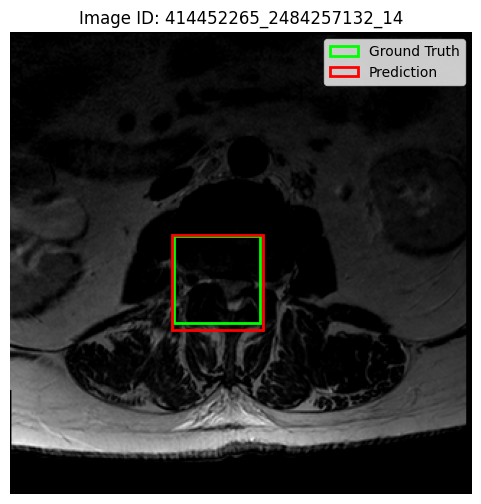

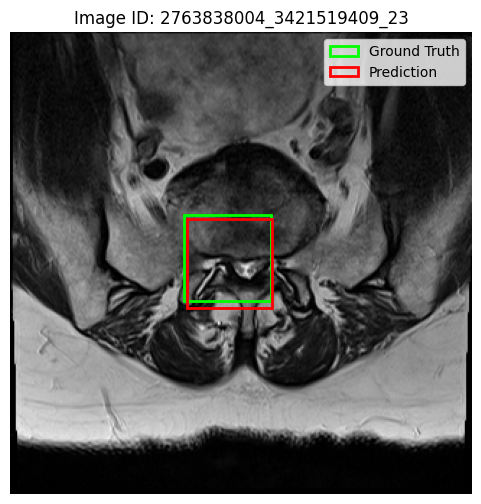

Skipping (no prediction): 1529391466_3179175659_12


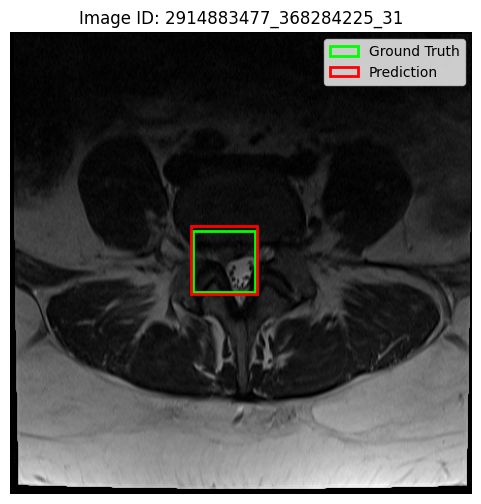

Skipping (no prediction): 3486932462_3487649104_5


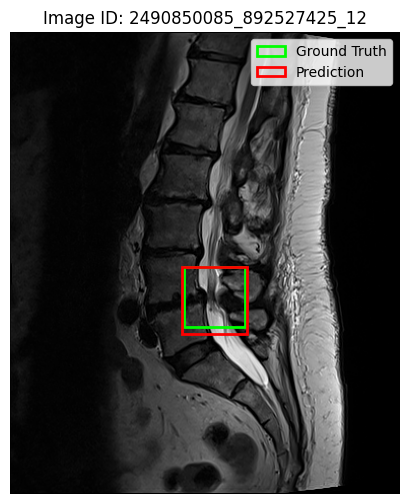

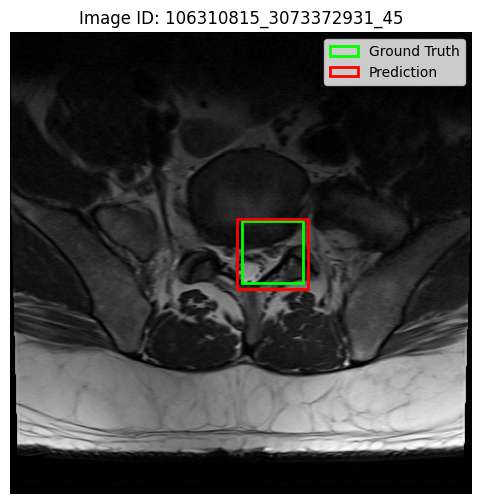

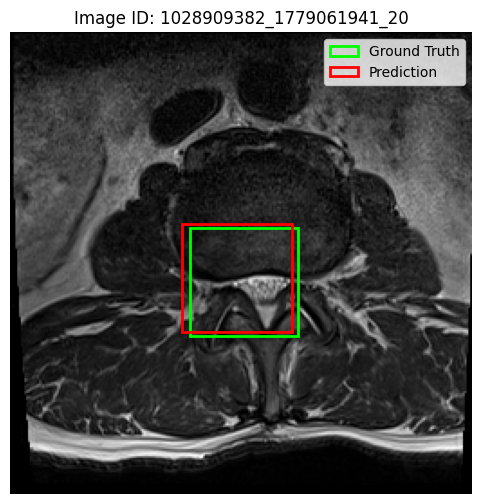

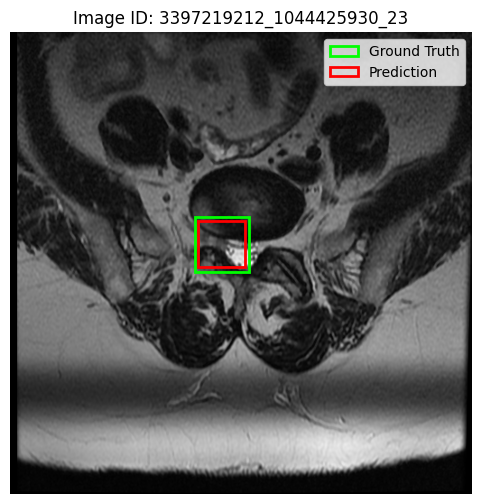

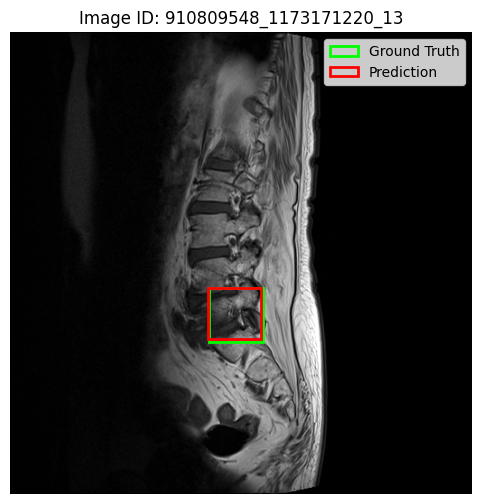

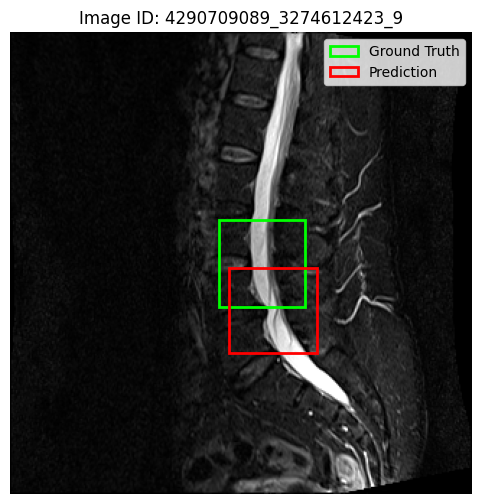

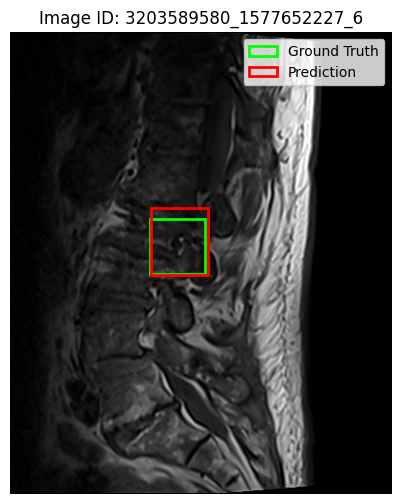

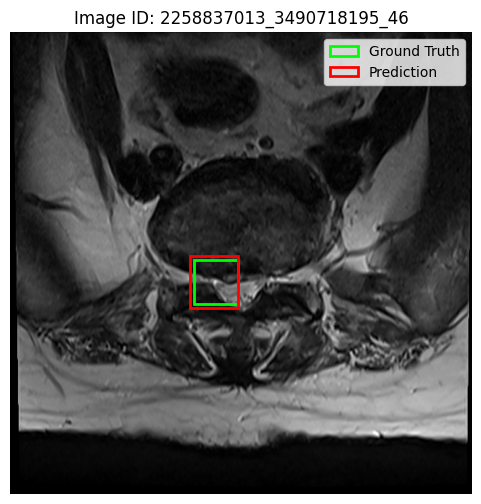

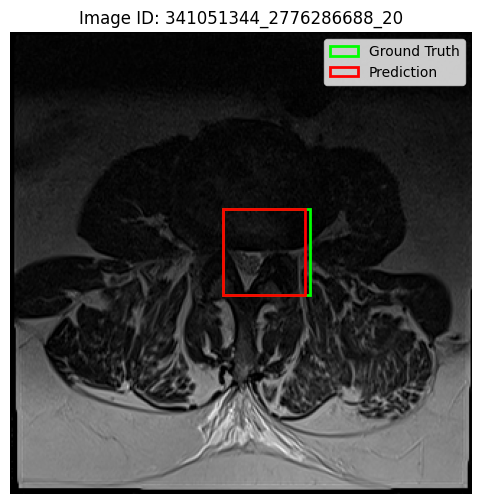

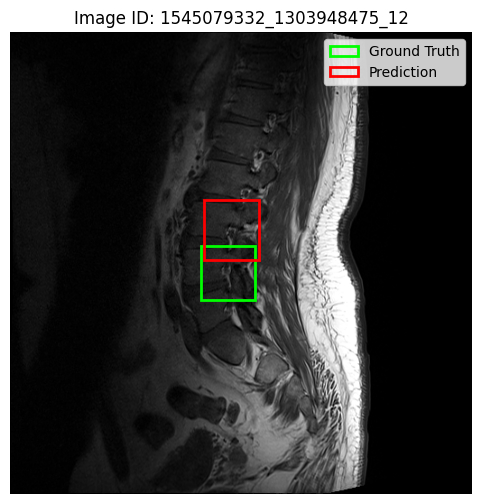

In [ ]:
# ----------------------------------------
# Visualize Ground Truth vs Predicted Bounding Boxes
# ----------------------------------------
# Paths and constants
image_dir = "/content/train_images"
box_size = 60
half = box_size // 2

# Sample a few rows from validation set
sample_validation = df_sample_val.sample(n=15, random_state=42)

for idx, row in sample_validation.iterrows():
    study_id = str(row["study_id"])
    series_id = str(row["series_id"])
    instance = str(row["instance_number"])
    image_id = f"{study_id}_{series_id}_{instance}"

    # GT bounding box centered at (x, y)
    x, y = int(row["x"]), int(row["y"])
    xmin_gt = max(x - half, 0)
    ymin_gt = max(y - half, 0)
    xmax_gt = x + half
    ymax_gt = y + half

    # Skip if no predictions for this image
    if image_id not in df_predicted_boxes["Image_ID"].values:
        print(f"Skipping (no prediction): {image_id}")
        continue

    # Get all predicted boxes for this image
    preds = df_predicted_boxes[df_predicted_boxes["Image_ID"] == image_id].copy()

    # Find predicted box whose center is closest to GT center
    gt_cx, gt_cy = (xmin_gt + xmax_gt) / 2, (ymin_gt + ymax_gt) / 2

    def center_dist(row):
        pred_cx = (row["xmin"] + row["xmax"]) / 2
        pred_cy = (row["ymin"] + row["ymax"]) / 2
        return np.sqrt((gt_cx - pred_cx)**2 + (gt_cy - pred_cy)**2)

    preds["center_dist"] = preds.apply(center_dist, axis=1)
    pred_row = preds.loc[preds["center_dist"].idxmin()]

    xmin_pred = int(pred_row["xmin"])
    ymin_pred = int(pred_row["ymin"])
    xmax_pred = int(pred_row["xmax"])
    ymax_pred = int(pred_row["ymax"])

    # Load DICOM image
    dcm_path = os.path.join(image_dir, study_id, series_id, f"{instance}.dcm")
    if not os.path.exists(dcm_path):
        print(f"Missing DICOM: {dcm_path}")
        continue

    ds = dcmread(dcm_path)
    image = apply_voi_lut(ds.pixel_array, ds).astype("float32")
    image = (image - image.min()) / (image.max() - image.min())
    image = (image * 255).astype("uint8")
    image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    # Visualize
    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb, cmap="gray")

    # Ground truth in green
    plt.gca().add_patch(plt.Rectangle(
        (xmin_gt, ymin_gt), box_size, box_size,
        linewidth=2, edgecolor='lime', facecolor='none', label="Ground Truth"
    ))

    # Predicted in red
    plt.gca().add_patch(plt.Rectangle(
        (xmin_pred, ymin_pred), xmax_pred - xmin_pred, ymax_pred - ymin_pred,
        linewidth=2, edgecolor='red', facecolor='none', label="Prediction"
    ))

    plt.title(f"Image ID: {image_id}")
    plt.legend()
    plt.axis("off")
    plt.show()


# Step 5: Use pretrained Resnet50 to get last layer features

In [ ]:
# ----------------------------------------
# Extract ResNet Features
# ----------------------------------------

# Load ResNet Feature Extractor
resnet = models.resnet50(pretrained=True)
resnet.fc = torch.nn.Identity()
resnet.eval()
resnet.to(device)

# Define Transform
transform_resnet = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Main Feature Extraction Function (Stores only true_class_id)
def extract_features_lumbar(df, image_root, save_path, is_training=True):
    extracted_features = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        image_id = row["Image_ID"]
        try:
            study_id, series_id, instance_number = image_id.split("_")
            dcm_path = os.path.join(image_root, study_id, series_id, f"{instance_number}.dcm")

        except:
            continue

        if not os.path.exists(dcm_path):
            continue

        try:
            ds = pydicom.dcmread(dcm_path)
            img = apply_voi_lut(ds.pixel_array, ds).astype("float32")
            img = (img - img.min()) / (img.max() - img.min())
            img = (img * 255).astype("uint8")
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        except:
            continue

        xmin, ymin, xmax, ymax = map(int, [row["xmin"], row["ymin"], row["xmax"], row["ymax"]])
        cropped = img_rgb[ymin:ymax, xmin:xmax]

        if cropped.size == 0:
            print(f"Empty crop for {image_id} with box ({xmin}, {ymin}, {xmax}, {ymax})")
            continue

        try:
            cropped_tensor = transform_resnet(cropped).unsqueeze(0).to(device)
            with torch.no_grad():
                feature_vector = resnet(cropped_tensor).cpu().numpy().flatten()
        except:
            continue

        # Use single true_class_id instead of level/condition
        if is_training:
          true_class_id = int(row["class_id"])

          if true_class_id is None:
            continue
        else:
          true_class_id = None


        extracted_features.append([
            image_id, *feature_vector, true_class_id
        ])

    # Handle empty feature list
    if len(extracted_features) == 0:
        print("No features extracted. Skipping save.")
        return pd.DataFrame()

    # Infer feature columns
    num_feats = len(extracted_features[0]) - 2  # one for image_id, one for class_id
    feature_cols = [f"feat_{i}" for i in range(num_feats)]
    columns = ["Image_ID"] + feature_cols + ["class_id"]

    df_features = pd.DataFrame(extracted_features, columns=columns)
    df_features.to_csv(save_path, index=False)
    print(f"Features saved to {save_path}")
    return df_features


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s]


# Extract features for train and val from pretrained resnet50

In [ ]:
# ----------------------------------------
# BLOCK: Extract Features for Training and Validation (LEVEL only, No series_description)
# ----------------------------------------

# Training features (with label = level)
extracted_features_train = extract_features_lumbar(
    df=df_sample_train,
    image_root="/content/train_images",
    save_path="/content/extracted_features_train_lumbar.csv",
    is_training=True
)

# Validation features (no label)
extracted_features_val = extract_features_lumbar(
    df=df_predicted_boxes,
    image_root="/content/train_images",
    save_path="/content/extracted_features_val_lumbar.csv",
    is_training=False
)


# Drop rows with missing class_id immediately after feature extraction
extracted_features_train = extracted_features_train.dropna(subset=["class_id"]).copy()
print(f" Training rows after dropping NaNs in class_id: {len(extracted_features_train)}")

# Drop unused class_id column from validation set
extracted_features_val = extracted_features_val.drop(columns=["class_id"])


100%|██████████| 4592/4592 [01:23<00:00, 55.24it/s]


Features saved to /content/extracted_features_train_lumbar.csv


100%|██████████| 1072/1072 [00:19<00:00, 56.12it/s]


Features saved to /content/extracted_features_val_lumbar.csv
 Training rows after dropping NaNs in class_id: 4592


# Predict Class labels with PRE-Trained Resnet50 - (not trained on our data)

In [ ]:
# --------------------------------------------------------
# BLOCK: Predict Class_ID Directly Using Full ResNet-50 (26 Classes)
# --------------------------------------------------------
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define Transform for ResNet
transform_resnet = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load Full ResNet Model with 26-Class Head
resnet = models.resnet50(pretrained=True)
resnet.fc = nn.Linear(2048, 26)  # 26 = 1 background + 25 condition-level classes
resnet.to(device)


resnet.eval()

# ✅ Define Prediction Function
def predict_class_id_with_resnet(df, image_root, save_path):
    predictions = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        image_id = row["Image_ID"]

        try:
            study_id, series_id, instance_number = image_id.split("_")
            dcm_path = os.path.join(image_root, study_id, series_id, f"{instance_number}.dcm")
        except:
            continue

        if not os.path.exists(dcm_path):
            continue

        try:
            ds = pydicom.dcmread(dcm_path)
            img = apply_voi_lut(ds.pixel_array, ds).astype("float32")
            img = (img - img.min()) / (img.max() - img.min())
            img = (img * 255).astype("uint8")
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        except:
            continue

        xmin, ymin, xmax, ymax = map(int, [row["xmin"], row["ymin"], row["xmax"], row["ymax"]])
        cropped = img_rgb[ymin:ymax, xmin:xmax]

        if cropped.size == 0:
            print(f" Empty crop for {image_id} with box ({xmin}, {ymin}, {xmax}, {ymax})")
            continue

        try:
            cropped_tensor = transform_resnet(cropped).unsqueeze(0).to(device)
            with torch.no_grad():
                logits = resnet(cropped_tensor)
                pred_class = torch.argmax(logits, dim=1).item()
        except:
            continue

        predictions.append({
            "Image_ID": image_id,
            "Predicted_Class_ID": pred_class
        })

    # Save to CSV
    df_preds = pd.DataFrame(predictions)
    df_preds.to_csv(save_path, index=False)
    print(f"Predictions saved to: {save_path}")

    return df_preds

image_root = "/content/train_images"  # or the path to the DICOM folder
save_path = "/content/resnet_direct_predictions.csv"

df_predicted_resnet = predict_class_id_with_resnet(df_predicted_boxes, image_root, save_path)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 1072/1072 [00:18<00:00, 56.54it/s]


Predictions saved to: /content/resnet_direct_predictions.csv


In [ ]:
# --------------------------------------------------------
# Evaluate condition-level set accuracy per image_id using ResNet predictions (with IoU)
# --------------------------------------------------------
# Create mapping of true affected condition-levels per image
true_map = defaultdict(set)

for _, row in df_sample_val.iterrows():
    if row["severity_code"] in [1, 2]:  # Only affected
        decoded = decode_class_id(row["class_id"])
        key = f"{decoded['condition_id']}_{decoded['level_id']}"
        true_map[row["Image_ID"]].add(key)

# Create mapping of predicted condition-levels per image (from ResNet)
pred_map = defaultdict(set)

for _, row in df_predicted_resnet.iterrows():
    decoded = decode_class_id(row["Predicted_Class_ID"])
    key = f"{decoded['condition_id']}_{decoded['level_id']}"
    pred_map[row["Image_ID"]].add(key)

# Evaluate per-image match quality
total_images = 0
exact_match = 0
match_100 = 0
match_75 = 0
match_50 = 0
iou_scores = []

for image_id in true_map:
    true_set = true_map[image_id]
    pred_set = pred_map.get(image_id, set())

    if not true_set and not pred_set:
        exact_match += 1
        match_100 += 1
        match_75 += 1
        match_50 += 1
        iou_scores.append(1.0)
    else:
        intersection = true_set & pred_set
        union = true_set | pred_set
        iou = len(intersection) / len(union) if union else 1.0
        iou_scores.append(iou)

        if pred_set == true_set:
            exact_match += 1
        if len(intersection) / len(true_set) >= 1.00:
            match_100 += 1
        if len(intersection) / len(true_set) >= 0.75:
            match_75 += 1
        if len(intersection) / len(true_set) >= 0.50:
            match_50 += 1

    total_images += 1

# Final metrics
mean_iou = sum(iou_scores) / total_images if total_images else 0.0

print(" Evaluation Metrics per Image_ID (ResNet Prediction):")
print(f"Exact Set Match (pred_set == true_set):     {exact_match}/{total_images} → {exact_match / total_images:.4f}")
print(f"≥100% Match (full recall of true set):     {match_100}/{total_images} → {match_100 / total_images:.4f}")
print(f"≥75%  Match (partial recall):              {match_75}/{total_images} → {match_75 / total_images:.4f}")
print(f"≥50%  Match (weak recall):                 {match_50}/{total_images} → {match_50 / total_images:.4f}")
print(f"Mean IoU across all images:               {mean_iou:.4f}")


 Evaluation Metrics per Image_ID (ResNet Prediction):
Exact Set Match (pred_set == true_set):     2/374 → 0.0053
≥100% Match (full recall of true set):     3/374 → 0.0080
≥75%  Match (partial recall):              3/374 → 0.0080
≥50%  Match (weak recall):                 3/374 → 0.0080
Mean IoU across all images:               0.0067


# Step 6: Retrain resnet50 on Lumbar Spine data

In [ ]:
# --------------------------------------------------------
# Retrain ResNet-50 on Cropped DICOMs (25-Class Classification)
# --------------------------------------------------------

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
transform_resnet = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Custom Dataset
class LumbarDataset(Dataset):
    def __init__(self, df, image_root, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = row["Image_ID"]
        class_id = int(row["class_id"])

        try:
            study_id, series_id, instance_number = image_id.split("_")
            dcm_path = os.path.join(self.image_root, study_id, series_id, f"{instance_number}.dcm")
            ds = pydicom.dcmread(dcm_path)
            img = apply_voi_lut(ds.pixel_array, ds).astype("float32")
            img = (img - img.min()) / (img.max() - img.min())
            img = (img * 255).astype("uint8")
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

            xmin, ymin, xmax, ymax = map(int, [row["xmin"], row["ymin"], row["xmax"], row["ymax"]])
            cropped = img_rgb[ymin:ymax, xmin:xmax]

            if cropped.size == 0:
                raise ValueError("Empty crop")

            if self.transform:
                cropped = self.transform(cropped)

            return cropped, class_id

        except Exception as e:
            # Return a dummy black image and ignore label to avoid crashing
            dummy = torch.zeros((3, 224, 224))
            return dummy, 0

# Create Dataset and Dataloader
train_dataset = LumbarDataset(df_sample_train, image_root="/content/train_images", transform=transform_resnet)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)

# Define Model
resnet = models.resnet50(pretrained=True)
resnet.fc = nn.Linear(2048, 26)  # 26-class classification
resnet = resnet.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=1e-4)

# Training Loop
num_epochs = 5  # You can increase
resnet.train()

start_time = time.time()

for epoch in range(num_epochs):
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = resnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f" Epoch {epoch+1}: Loss = {epoch_loss:.4f}")

end_time = time.time()  # End timer

print(f" Total ResNet training time: {end_time - start_time:.2f} seconds")

# Save Trained Weights
torch.save(resnet.state_dict(), "/content/resnet50_trained_26class.pth")
print("Model saved: resnet50_trained_26class.pth")


Epoch 1/5: 100%|██████████| 144/144 [00:26<00:00,  5.52it/s]


 Epoch 1: Loss = 2.1272


Epoch 2/5: 100%|██████████| 144/144 [00:25<00:00,  5.68it/s]


 Epoch 2: Loss = 1.2932


Epoch 3/5: 100%|██████████| 144/144 [00:25<00:00,  5.71it/s]


 Epoch 3: Loss = 0.8947


Epoch 4/5: 100%|██████████| 144/144 [00:25<00:00,  5.68it/s]


 Epoch 4: Loss = 0.5544


Epoch 5/5: 100%|██████████| 144/144 [00:25<00:00,  5.65it/s]


 Epoch 5: Loss = 0.2884
 Total ResNet training time: 127.53 seconds
Model saved: resnet50_trained_26class.pth


# Predict class labels using RE-trained Resnet50

In [ ]:
# --------------------------------------------------------
# Predict class_id using fine-tuned ResNet-50 (on df_predicted_boxes)
# --------------------------------------------------------

# Load trained ResNet model
resnet = models.resnet50(pretrained=False)
resnet.fc = nn.Linear(2048, 26)  # 26-class classifier
resnet.load_state_dict(torch.load("/content/resnet50_trained_26class.pth"))
resnet.to(device)
resnet.eval()

# Image transform
transform_resnet = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Predict class_id for each row in df_predicted_boxes
def predict_class_ids(df, image_root, save_path):
    predictions = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        image_id = row["Image_ID"]

        try:
            study_id, series_id, instance_number = image_id.split("_")
            dcm_path = os.path.join(image_root, study_id, series_id, f"{instance_number}.dcm")
            ds = pydicom.dcmread(dcm_path)
            img = apply_voi_lut(ds.pixel_array, ds).astype("float32")
            img = (img - img.min()) / (img.max() - img.min())
            img = (img * 255).astype("uint8")
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

            xmin, ymin, xmax, ymax = map(int, [row["xmin"], row["ymin"], row["xmax"], row["ymax"]])
            cropped = img_rgb[ymin:ymax, xmin:xmax]

            if cropped.size == 0:
                continue

            cropped_tensor = transform_resnet(cropped).unsqueeze(0).to(device)

            with torch.no_grad():
                logits = resnet(cropped_tensor)
                pred_class_id = torch.argmax(logits, dim=1).item()

            predictions.append({
                "Image_ID": image_id,
                "Predicted_Class_ID": pred_class_id
            })

        except:
            continue

    df_preds = pd.DataFrame(predictions)
    df_preds.to_csv(save_path, index=False)
    print(f"Predictions saved to: {save_path}")
    return df_preds

# Run Prediction
image_root = "/content/train_images"
save_path = "/content/resnet_finetuned_predictions.csv"

df_predicted_resnet_trained = predict_class_ids(df_predicted_boxes, image_root, save_path)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
100%|██████████| 1072/1072 [00:19<00:00, 55.97it/s]


Predictions saved to: /content/resnet_finetuned_predictions.csv


In [ ]:
# --------------------------------------------------------
# Set-Level Accuracy Evaluation using Trained ResNet Predictions
# --------------------------------------------------------

# Ground truth map
true_map = defaultdict(set)

for _, row in df_sample_val.iterrows():
    if row["severity_code"] in [1, 2]:
        decoded = decode_class_id(row["class_id"])
        key = f"{decoded['condition_id']}_{decoded['level_id']}"
        true_map[row["Image_ID"]].add(key)

# Prediction map (from trained ResNet)
pred_map = defaultdict(set)

for _, row in df_predicted_resnet_trained.iterrows():
    decoded = decode_class_id(row["Predicted_Class_ID"])
    key = f"{decoded['condition_id']}_{decoded['level_id']}"
    pred_map[row["Image_ID"]].add(key)

# Accuracy stats
total_images = 0
exact_match = 0
match_100 = 0
match_75 = 0
match_50 = 0

for image_id in true_map:
    true_set = true_map[image_id]
    pred_set = pred_map.get(image_id, set())

    if not true_set and not pred_set:
        exact_match += 1
        match_100 += 1
        match_75 += 1
        match_50 += 1
    else:
        intersection = true_set & pred_set
        if pred_set == true_set:
            exact_match += 1
        if len(intersection) / len(true_set) >= 1.00:
            match_100 += 1
        if len(intersection) / len(true_set) >= 0.75:
            match_75 += 1
        if len(intersection) / len(true_set) >= 0.50:
            match_50 += 1

    total_images += 1

# Print results
print("Evaluation Metrics per Image_ID (Trained ResNet):")
print(f"Exact Set Match (pred_set == true_set):     {exact_match}/{total_images} → {exact_match / total_images:.4f}")
print(f"≥100% Match (full recall of true set):     {match_100}/{total_images} → {match_100 / total_images:.4f}")
print(f"≥75%  Match (partial recall):              {match_75}/{total_images} → {match_75 / total_images:.4f}")
print(f"≥50%  Match (weak recall):                 {match_50}/{total_images} → {match_50 / total_images:.4f}")


Evaluation Metrics per Image_ID (Trained ResNet):
Exact Set Match (pred_set == true_set):     29/374 → 0.0775
≥100% Match (full recall of true set):     154/374 → 0.4118
≥75%  Match (partial recall):              154/374 → 0.4118
≥50%  Match (weak recall):                 158/374 → 0.4225


# Extract features for train and val using RE-trained Resnet50

In [ ]:
# --------------------------------------------------------
# BLOCK 12 (Final): Extract Features from Trained ResNet-50 (26-Class Model)
# --------------------------------------------------------

# Step 1: Load trained model and restore full structure
resnet = models.resnet50(pretrained=False)
resnet.fc = nn.Linear(2048, 26)  # Match training structure

# Step 2: Load trained weights
resnet.load_state_dict(torch.load("/content/resnet50_trained_26class.pth"))

# Step 3: Switch to feature extractor
resnet.fc = nn.Identity()

# Step 4: Finalize model
resnet.to(device)
resnet.eval()

# Image transform
transform_resnet = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Main Feature Extraction Function
def extract_features_lumbar_retrained(df, image_root, save_path, is_training=True):
    extracted_features = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        image_id = row["Image_ID"]
        try:
            study_id, series_id, instance_number = image_id.split("_")
            dcm_path = os.path.join(image_root, study_id, series_id, f"{instance_number}.dcm")
        except:
            continue

        if not os.path.exists(dcm_path):
            continue

        try:
            ds = pydicom.dcmread(dcm_path)
            img = apply_voi_lut(ds.pixel_array, ds).astype("float32")
            img = (img - img.min()) / (img.max() - img.min())
            img = (img * 255).astype("uint8")
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        except:
            continue

        xmin, ymin, xmax, ymax = map(int, [row["xmin"], row["ymin"], row["xmax"], row["ymax"]])
        cropped = img_rgb[ymin:ymax, xmin:xmax]

        if cropped.size == 0:
            print(f" Empty crop for {image_id} with box ({xmin}, {ymin}, {xmax}, {ymax})")
            continue

        try:
            cropped_tensor = transform_resnet(cropped).unsqueeze(0).to(device)
            with torch.no_grad():
                feature_vector = resnet(cropped_tensor).cpu().numpy().flatten()
        except:
            continue

        if is_training:
            true_class_id = int(row["class_id"]) if pd.notnull(row["class_id"]) else None
            if true_class_id is None:
                continue
        else:
            true_class_id = None

        extracted_features.append([
            image_id, *feature_vector, true_class_id
        ])

    if len(extracted_features) == 0:
        print(" No features extracted. Skipping save.")
        return pd.DataFrame()

    num_feats = len(extracted_features[0]) - 2  # exclude image_id and class_id
    feature_cols = [f"feat_{i}" for i in range(num_feats)]
    columns = ["Image_ID"] + feature_cols + ["class_id"]

    df_features = pd.DataFrame(extracted_features, columns=columns)
    df_features.to_csv(save_path, index=False)
    print(f"Features saved to {save_path}")
    return df_features


In [ ]:
# ----------------------------------------
# BLOCK: Extract Features for Training and Validation (LEVEL only, No series_description)
# ----------------------------------------

#Training features (with label = level)
extracted_features_train_retrained = extract_features_lumbar_retrained(
    df=df_sample_train,
    image_root="/content/train_images",
    save_path="/content/extracted_features_train_lumbar_retrained.csv",
    is_training=True
)

#Validation features (no label)
extracted_features_val_retrained = extract_features_lumbar_retrained(
    df=df_predicted_boxes,
    image_root="/content/train_images",
    save_path="/content/extracted_features_val_lumbar_retrained.csv",
    is_training=False
)


# Drop rows with missing class_id immediately after feature extraction
extracted_features_train_retrained = extracted_features_train_retrained.dropna(subset=["class_id"]).copy()
print(f"Training rows after dropping NaNs in class_id: {len(extracted_features_train_retrained)}")

# Drop unused class_id column from validation set
extracted_features_val_retrained = extracted_features_val_retrained.drop(columns=["class_id"])


100%|██████████| 4592/4592 [01:22<00:00, 55.38it/s]


Features saved to /content/extracted_features_train_lumbar_retrained.csv


100%|██████████| 1072/1072 [00:19<00:00, 55.41it/s]


Features saved to /content/extracted_features_val_lumbar_retrained.csv
Training rows after dropping NaNs in class_id: 4592


# **Now train ML models - RF, SVM, Jacobi-Logit with Resnet50 last layer features ->**

# Step 7: Train Ml models Using Pre_Trained Resnet50 last layer (Full) features ->

**Random Forest**

In [ ]:
# --------------------------------------------------------
# RF: Train Random Forest to Predict 25-class
# --------------------------------------------------------
X_train = extracted_features_train.drop(columns=["Image_ID", "class_id"], errors="ignore")
y_train = extracted_features_train["class_id"]

# Train Random Forest model
model_rf = RandomForestClassifier(n_estimators=500, random_state=42)

start_time = time.time()

model_rf.fit(X_train, y_train)

end_time = time.time()
print(f"Random Forest training time: {end_time - start_time:.2f} seconds")

print("Random Forest model trained to predict 25-class `class_id`.")

# Prepare validation features
val_image_ids = extracted_features_val["Image_ID"]
X_val = extracted_features_val.drop(columns=["Image_ID", "class_id"], errors="ignore")

# Predict class_id on validation set
y_pred_class_ids = model_rf.predict(X_val)

# Store predictions
df_predicted_rf = pd.DataFrame({
    "Image_ID": val_image_ids,
    "Predicted_Class_ID": y_pred_class_ids
})

# Save predictions
df_predicted_rf.to_csv("/content/model_predictions_class_id_rf.csv", index=False)
print("📁 Saved Random Forest predictions to /content/model_predictions_class_id_rf.csv")


Random Forest training time: 150.54 seconds
Random Forest model trained to predict 25-class `class_id`.
📁 Saved Random Forest predictions to /content/model_predictions_class_id_rf.csv


In [ ]:
# --------------------------------------------------------
# Evaluate condition-level set accuracy per image_id
# --------------------------------------------------------
# Create mapping of true affected condition-levels per image
true_map = defaultdict(set)

for _, row in df_sample_val.iterrows():
    if row["severity_code"] in [1, 2]:  # Only affected
        decoded = decode_class_id(row["class_id"])
        key = f"{decoded['condition_id']}_{decoded['level_id']}"
        true_map[row["Image_ID"]].add(key)

# Create mapping of predicted condition-levels per image
pred_map = defaultdict(set)

for _, row in df_predicted_rf.iterrows():
    decoded = decode_class_id(row["Predicted_Class_ID"])
    key = f"{decoded['condition_id']}_{decoded['level_id']}"
    pred_map[row["Image_ID"]].add(key)

# Evaluate per-image match quality
total_images = 0
exact_match = 0
match_100 = 0
match_75 = 0
match_50 = 0
iou_scores = []

for image_id in true_map:
    true_set = true_map[image_id]
    pred_set = pred_map.get(image_id, set())

    if not true_set and not pred_set:
        exact_match += 1
        match_100 += 1
        match_75 += 1
        match_50 += 1
        iou_scores.append(1.0)
    else:
        intersection = true_set & pred_set
        union = true_set | pred_set

        iou = len(intersection) / len(union) if union else 1.0
        iou_scores.append(iou)

        if pred_set == true_set:
            exact_match += 1
        if len(intersection) / len(true_set) >= 1.00:
            match_100 += 1
        if len(intersection) / len(true_set) >= 0.75:
            match_75 += 1
        if len(intersection) / len(true_set) >= 0.50:
            match_50 += 1

    total_images += 1

# Final metrics
mean_iou = sum(iou_scores) / total_images if total_images else 0.0

print("Evaluation Metrics per Image_ID (on affected class set match) - Random Forest:")
print(f"Exact Set Match (pred_set == true_set):     {exact_match}/{total_images} → {exact_match / total_images:.4f}")
print(f"≥100% Match (full recall of true set):     {match_100}/{total_images} → {match_100 / total_images:.4f}")
print(f"≥75%  Match (partial recall):              {match_75}/{total_images} → {match_75 / total_images:.4f}")
print(f"≥50%  Match (weak recall):                 {match_50}/{total_images} → {match_50 / total_images:.4f}")
print(f"Mean IoU across all images:               {mean_iou:.4f}")


Evaluation Metrics per Image_ID (on affected class set match) - Random Forest:
Exact Set Match (pred_set == true_set):     14/374 → 0.0374
≥100% Match (full recall of true set):     48/374 → 0.1283
≥75%  Match (partial recall):              48/374 → 0.1283
≥50%  Match (weak recall):                 51/374 → 0.1364
Mean IoU across all images:               0.0789


**SVM**

In [ ]:
# --------------------------------------------------------
# SVM: Train SVM to Predict 25-class
# --------------------------------------------------------
# Select training and validation features
X_train = extracted_features_train.drop(columns=["Image_ID", "class_id"], errors="ignore")
y_train = extracted_features_train["class_id"]

X_val = extracted_features_val.drop(columns=["Image_ID", "class_id"], errors="ignore")
val_image_ids = extracted_features_val["Image_ID"]

# Train SVM model with timing
model_svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

start_time = time.time()
model_svm.fit(X_train, y_train)
end_time = time.time()

print("SVM model trained to predict 25-class `class_id`.")
print(f"Training time: {end_time - start_time:.2f} seconds")

# Predict on validation set
y_pred_svm = model_svm.predict(X_val)

# Store predictions
df_predicted_svm = pd.DataFrame({
    "Image_ID": val_image_ids,
    "Predicted_Class_ID": y_pred_svm
})

# Save predictions
df_predicted_svm.to_csv("/content/model_predictions_class_id_svm.csv", index=False)
print("📁 Saved SVM predictions to /content/model_predictions_class_id_svm.csv")


SVM model trained to predict 25-class `class_id`.
Training time: 18.23 seconds
📁 Saved SVM predictions to /content/model_predictions_class_id_svm.csv


In [ ]:
# --------------------------------------------------------
# Evaluate condition-level set accuracy for SVM predictions
# --------------------------------------------------------

# Create mapping of true affected condition-levels per image
true_map = defaultdict(set)

for _, row in df_sample_val.iterrows():
    if row["severity_code"] in [1, 2]:  # Only affected
        decoded = decode_class_id(row["class_id"])
        key = f"{decoded['condition_id']}_{decoded['level_id']}"
        true_map[row["Image_ID"]].add(key)

# Create mapping of predicted condition-levels from SVM output
pred_map = defaultdict(set)

for _, row in df_predicted_svm.iterrows():
    decoded = decode_class_id(row["Predicted_Class_ID"])
    key = f"{decoded['condition_id']}_{decoded['level_id']}"
    pred_map[row["Image_ID"]].add(key)

# Evaluate per-image match quality
total_images = 0
exact_match = 0
match_100 = 0
match_75 = 0
match_50 = 0
iou_scores = []

for image_id in true_map:
    true_set = true_map[image_id]
    pred_set = pred_map.get(image_id, set())

    if not true_set and not pred_set:
        exact_match += 1
        match_100 += 1
        match_75 += 1
        match_50 += 1
        iou_scores.append(1.0)
    else:
        intersection = true_set & pred_set
        union = true_set | pred_set

        iou = len(intersection) / len(union) if union else 1.0
        iou_scores.append(iou)

        if pred_set == true_set:
            exact_match += 1
        if len(intersection) / len(true_set) >= 1.00:
            match_100 += 1
        if len(intersection) / len(true_set) >= 0.75:
            match_75 += 1
        if len(intersection) / len(true_set) >= 0.50:
            match_50 += 1

    total_images += 1

# Final metrics
mean_iou = sum(iou_scores) / total_images if total_images else 0.0

print("Evaluation Metrics per Image_ID - SVM :")
print(f"Exact Set Match (pred_set == true_set):     {exact_match}/{total_images} → {exact_match / total_images:.4f}")
print(f"≥100% Match (full recall of true set):     {match_100}/{total_images} → {match_100 / total_images:.4f}")
print(f"≥75%  Match (partial recall):              {match_75}/{total_images} → {match_75 / total_images:.4f}")
print(f"≥50%  Match (weak recall):                 {match_50}/{total_images} → {match_50 / total_images:.4f}")
print(f"Mean IoU across all images:               {mean_iou:.4f}")


Evaluation Metrics per Image_ID - SVM :
Exact Set Match (pred_set == true_set):     16/374 → 0.0428
≥100% Match (full recall of true set):     66/374 → 0.1765
≥75%  Match (partial recall):              66/374 → 0.1765
≥50%  Match (weak recall):                 69/374 → 0.1845
Mean IoU across all images:               0.1045


**Jacobi-Logit model**

In [ ]:
#-----------------------------------------------
# Jacobi-Logit: train the model for 25 class
#-----------------------------------------------

# Select training and validation features
X_train = extracted_features_train.drop(columns=["Image_ID", "class_id"], errors="ignore")
y_train = extracted_features_train["class_id"]

X_val = extracted_features_val.drop(columns=["Image_ID", "class_id"], errors="ignore")
val_image_ids = extracted_features_val["Image_ID"]

# Constants
a = b = 1/2
k = 1

# One-hot encode class labels
encoder = OneHotEncoder(sparse_output=False)
Y_train_reshaped = np.array(y_train).reshape(-1, 1)
Y_train_onehot = encoder.fit_transform(Y_train_reshaped)
class_labels = encoder.categories_[0].astype(int)

# Prepare dictionaries to store results
eta_dict = {}
beta_hat_dict = {}
lambda_dict = {}

start_time = time.time()

# Precompute (XᵗX)⁻¹
XTX_inv = inv(X_train.T @ X_train)
A_matrix = XTX_inv @ X_train.T

X_val_np = X_val.to_numpy()

# Loop over each class label
for idx, label in enumerate(class_labels):
    y_class = Y_train_onehot[:, idx]
    eta = np.log((y_class + a) / (1 + (1 / (k * b))))
    eta_dict[label] = eta
    beta_hat_dict[label] = A_matrix @ eta

    z = X_val_np @ beta_hat_dict[label]

    lambda_dict[label] = np.exp(z)


# Predict
lambda_df = pd.DataFrame(lambda_dict)
y_pred = lambda_df.idxmax(axis=1)

end_time = time.time()
print(f"Jacobi model training + prediction time: {end_time - start_time:.2f} seconds")

df_predicted_jacobi = pd.DataFrame({
    "Image_ID": val_image_ids,
    "Predicted_Class_ID": y_pred
})



Jacobi model training + prediction time: 1.15 seconds


In [ ]:
# --------------------------------------------------------
# Evaluate condition-level set accuracy for Jacobi Prior predictions
# --------------------------------------------------------

# Ground truth mapping per image
true_map = defaultdict(set)

for _, row in df_sample_val.iterrows():
    if row["severity_code"] in [1, 2]:  # Only affected
        decoded = decode_class_id(row["class_id"])
        key = f"{decoded['condition_id']}_{decoded['level_id']}"
        true_map[row["Image_ID"]].add(key)

# Prediction mapping from Jacobi model
pred_map = defaultdict(set)

for _, row in df_predicted_jacobi.iterrows():
    decoded = decode_class_id(row["Predicted_Class_ID"])
    key = f"{decoded['condition_id']}_{decoded['level_id']}"
    pred_map[row["Image_ID"]].add(key)

# Evaluate per-image set match + IoU
total_images = 0
exact_match = 0
match_100 = 0
match_75 = 0
match_50 = 0
iou_scores = []

for image_id in true_map:
    true_set = true_map[image_id]
    pred_set = pred_map.get(image_id, set())

    if not true_set and not pred_set:
        exact_match += 1
        match_100 += 1
        match_75 += 1
        match_50 += 1
        iou_scores.append(1.0)
    else:
        intersection = true_set & pred_set
        union = true_set | pred_set
        iou = len(intersection) / len(union) if union else 1.0
        iou_scores.append(iou)

        if pred_set == true_set:
            exact_match += 1
        if len(intersection) / len(true_set) >= 1.00:
            match_100 += 1
        if len(intersection) / len(true_set) >= 0.75:
            match_75 += 1
        if len(intersection) / len(true_set) >= 0.50:
            match_50 += 1

    total_images += 1

# Final metrics
mean_iou = sum(iou_scores) / total_images if total_images else 0.0

print("Evaluation Metrics per Image_ID - Jacobi Prior Predictions:")
print(f"Exact Set Match (pred_set == true_set):     {exact_match}/{total_images} → {exact_match / total_images:.4f}")
print(f"≥100% Match (full recall of true set):     {match_100}/{total_images} → {match_100 / total_images:.4f}")
print(f"≥75%  Match (partial recall):              {match_75}/{total_images} → {match_75 / total_images:.4f}")
print(f"≥50%  Match (weak recall):                 {match_50}/{total_images} → {match_50 / total_images:.4f}")
print(f"Mean IoU across all images:               {mean_iou:.4f}")


Evaluation Metrics per Image_ID - Jacobi Prior Predictions:
Exact Set Match (pred_set == true_set):     22/374 → 0.0588
≥100% Match (full recall of true set):     118/374 → 0.3155
≥75%  Match (partial recall):              118/374 → 0.3155
≥50%  Match (weak recall):                 122/374 → 0.3262
Mean IoU across all images:               0.1700


# **Step 8: Now Run the RF, SVM, Jacobi-Logit with RE-Trained Resnet50 features (Full)**

**Random Forest**

In [ ]:
# --------------------------------------------------------
# RF: Train Random Forest to Predict 25-class
# --------------------------------------------------------
X_train = extracted_features_train_retrained.drop(columns=["Image_ID", "class_id"], errors="ignore")
y_train = extracted_features_train_retrained["class_id"]

# Train Random Forest model
model_rf_retrained = RandomForestClassifier(n_estimators=500, random_state=42)

start_time = time.time()

model_rf_retrained.fit(X_train, y_train)

end_time = time.time()
print(f"Random Forest training time: {end_time - start_time:.2f} seconds")

print("Random Forest model trained to predict 25-class (retrained weights).")

# Prepare validation features
val_image_ids = extracted_features_val_retrained["Image_ID"]
X_val = extracted_features_val_retrained.drop(columns=["Image_ID", "class_id"], errors="ignore")

# Predict class_id on validation set
y_pred_class_ids = model_rf_retrained.predict(X_val)

# Store predictions
df_predicted_rf_retrained = pd.DataFrame({
    "Image_ID": val_image_ids,
    "Predicted_Class_ID": y_pred_class_ids
})

# Save predictions
df_predicted_rf_retrained.to_csv("/content/model_predictions_class_id_rf_retrained.csv", index=False)
print("📁 Saved Random Forest predictions to /content/model_predictions_class_id_rf_retrained.csv")


Random Forest training time: 108.46 seconds
Random Forest model trained to predict 25-class (retrained weights).
📁 Saved Random Forest predictions to /content/model_predictions_class_id_rf_retrained.csv


In [ ]:
# --------------------------------------------------------
# Evaluate condition-level set accuracy per image_id
# --------------------------------------------------------

# Create mapping of true affected condition-levels per image
true_map = defaultdict(set)

for _, row in df_sample_val.iterrows():
    if row["severity_code"] in [1, 2]:  # Only affected
        decoded = decode_class_id(row["class_id"])
        key = f"{decoded['condition_id']}_{decoded['level_id']}"
        true_map[row["Image_ID"]].add(key)

# Create mapping of predicted condition-levels per image
pred_map = defaultdict(set)

for _, row in df_predicted_rf_retrained.iterrows():
    decoded = decode_class_id(row["Predicted_Class_ID"])
    key = f"{decoded['condition_id']}_{decoded['level_id']}"
    pred_map[row["Image_ID"]].add(key)

# Evaluate per-image match quality
total_images = 0
exact_match = 0
match_100 = 0
match_75 = 0
match_50 = 0
iou_scores = []

for image_id in true_map:
    true_set = true_map[image_id]
    pred_set = pred_map.get(image_id, set())

    if not true_set and not pred_set:
        exact_match += 1
        match_100 += 1
        match_75 += 1
        match_50 += 1
        iou_scores.append(1.0)
    else:
        intersection = true_set & pred_set
        union = true_set | pred_set

        iou = len(intersection) / len(union) if union else 1.0
        iou_scores.append(iou)

        if pred_set == true_set:
            exact_match += 1
        if len(intersection) / len(true_set) >= 1.00:
            match_100 += 1
        if len(intersection) / len(true_set) >= 0.75:
            match_75 += 1
        if len(intersection) / len(true_set) >= 0.50:
            match_50 += 1

    total_images += 1

# Final metrics
mean_iou = sum(iou_scores) / total_images if total_images else 0.0

print("Evaluation Metrics per Image_ID (on affected class set match) - Random Forest (Retrained weights):")
print(f"Exact Set Match (pred_set == true_set):     {exact_match}/{total_images} → {exact_match / total_images:.4f}")
print(f"≥100% Match (full recall of true set):     {match_100}/{total_images} → {match_100 / total_images:.4f}")
print(f"≥75%  Match (partial recall):              {match_75}/{total_images} → {match_75 / total_images:.4f}")
print(f"≥50%  Match (weak recall):                 {match_50}/{total_images} → {match_50 / total_images:.4f}")
print(f"Mean IoU across all images:               {mean_iou:.4f}")


Evaluation Metrics per Image_ID (on affected class set match) - Random Forest (Retrained weights):
Exact Set Match (pred_set == true_set):     21/374 → 0.0561
≥100% Match (full recall of true set):     174/374 → 0.4652
≥75%  Match (partial recall):              174/374 → 0.4652
≥50%  Match (weak recall):                 180/374 → 0.4813
Mean IoU across all images:               0.2472


**SVM**

In [ ]:
# --------------------------------------------------------
# SVM: Train SVM to Predict 25-class
# --------------------------------------------------------
# Select training and validation features
X_train = extracted_features_train_retrained.drop(columns=["Image_ID", "class_id"], errors="ignore")
y_train = extracted_features_train_retrained["class_id"]

X_val = extracted_features_val_retrained.drop(columns=["Image_ID", "class_id"], errors="ignore")
val_image_ids = extracted_features_val_retrained["Image_ID"]

# Train SVM model with timing
model_svm_retrained = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

start_time = time.time()
model_svm_retrained.fit(X_train, y_train)
end_time = time.time()

print("SVM model trained to predict 25-class (Retrained weights).")
print(f"Training time: {end_time - start_time:.2f} seconds")

# Predict on validation set
y_pred_svm = model_svm_retrained.predict(X_val)

# Store predictions
df_predicted_svm_retrained = pd.DataFrame({
    "Image_ID": val_image_ids,
    "Predicted_Class_ID": y_pred_svm
})

# Save predictions
df_predicted_svm_retrained.to_csv("/content/model_predictions_class_id_svm_retrained.csv", index=False)
print("📁 Saved SVM predictions to /content/model_predictions_class_id_svm_retrained.csv")


SVM model trained to predict 25-class (Retrained weights).
Training time: 3.16 seconds
📁 Saved SVM predictions to /content/model_predictions_class_id_svm_retrained.csv


In [ ]:
# --------------------------------------------------------
# Evaluate condition-level set accuracy for SVM predictions
# --------------------------------------------------------

# Create mapping of true affected condition-levels per image
true_map = defaultdict(set)

for _, row in df_sample_val.iterrows():
    if row["severity_code"] in [1, 2]:  # Only affected
        decoded = decode_class_id(row["class_id"])
        key = f"{decoded['condition_id']}_{decoded['level_id']}"
        true_map[row["Image_ID"]].add(key)

# Create mapping of predicted condition-levels from SVM output
pred_map = defaultdict(set)

for _, row in df_predicted_svm_retrained.iterrows():
    decoded = decode_class_id(row["Predicted_Class_ID"])
    key = f"{decoded['condition_id']}_{decoded['level_id']}"
    pred_map[row["Image_ID"]].add(key)

# Evaluate per-image match quality
total_images = 0
exact_match = 0
match_100 = 0
match_75 = 0
match_50 = 0
iou_scores = []

for image_id in true_map:
    true_set = true_map[image_id]
    pred_set = pred_map.get(image_id, set())

    if not true_set and not pred_set:
        exact_match += 1
        match_100 += 1
        match_75 += 1
        match_50 += 1
        iou_scores.append(1.0)
    else:
        intersection = true_set & pred_set
        union = true_set | pred_set

        iou = len(intersection) / len(union) if union else 1.0
        iou_scores.append(iou)

        if pred_set == true_set:
            exact_match += 1
        if len(intersection) / len(true_set) >= 1.00:
            match_100 += 1
        if len(intersection) / len(true_set) >= 0.75:
            match_75 += 1
        if len(intersection) / len(true_set) >= 0.50:
            match_50 += 1

    total_images += 1

# Final metrics
mean_iou = sum(iou_scores) / total_images if total_images else 0.0

print("Evaluation Metrics per Image_ID - SVM (Retrained weights) :")
print(f"Exact Set Match (pred_set == true_set):     {exact_match}/{total_images} → {exact_match / total_images:.4f}")
print(f"≥100% Match (full recall of true set):     {match_100}/{total_images} → {match_100 / total_images:.4f}")
print(f"≥75%  Match (partial recall):              {match_75}/{total_images} → {match_75 / total_images:.4f}")
print(f"≥50%  Match (weak recall):                 {match_50}/{total_images} → {match_50 / total_images:.4f}")
print(f"Mean IoU across all images:               {mean_iou:.4f}")


Evaluation Metrics per Image_ID - SVM (Retrained weights) :
Exact Set Match (pred_set == true_set):     20/374 → 0.0535
≥100% Match (full recall of true set):     178/374 → 0.4759
≥75%  Match (partial recall):              178/374 → 0.4759
≥50%  Match (weak recall):                 184/374 → 0.4920
Mean IoU across all images:               0.2495


**Jacobi-Logit model**

In [ ]:
#-----------------------------------------------
# Jacobi-Logit: Train Jacobi Logit model for 25 classes
#-----------------------------------------------
# Select training and validation features
X_train = extracted_features_train_retrained.drop(columns=["Image_ID", "class_id"], errors="ignore")
y_train = extracted_features_train_retrained["class_id"]

X_val = extracted_features_val_retrained.drop(columns=["Image_ID", "class_id"], errors="ignore")
val_image_ids = extracted_features_val_retrained["Image_ID"]

# Constants
a = b = 1/2
k = 1

# One-hot encode class labels
encoder = OneHotEncoder(sparse_output=False)
Y_train_reshaped = np.array(y_train).reshape(-1, 1)
Y_train_onehot = encoder.fit_transform(Y_train_reshaped)
class_labels = encoder.categories_[0].astype(int)

# Prepare dictionaries to store results
eta_dict = {}
beta_hat_dict = {}
lambda_dict = {}

start_time = time.time()

# Precompute (XᵗX)⁻¹
XTX_inv = inv(X_train.T @ X_train)
A_matrix = XTX_inv @ X_train.T

X_val_np = X_val.to_numpy()

# Loop over each class label
for idx, label in enumerate(class_labels):
    y_class = Y_train_onehot[:, idx]
    eta = np.log((y_class + a) / (1 + (1 / (k * b))))
    eta_dict[label] = eta
    beta_hat_dict[label] = A_matrix @ eta

    z = X_val_np @ beta_hat_dict[label]

    lambda_dict[label] = np.exp(z)


# Predict
lambda_df = pd.DataFrame(lambda_dict)
y_pred = lambda_df.idxmax(axis=1)

end_time = time.time()
print(f"Jacobi model (retrained weights) training + prediction time: {end_time - start_time:.2f} seconds")

df_predicted_jacobi_retrained = pd.DataFrame({
    "Image_ID": val_image_ids,
    "Predicted_Class_ID": y_pred
})



Jacobi model (retrained weights) training + prediction time: 1.38 seconds


In [ ]:
# --------------------------------------------------------
# Evaluate condition-level set accuracy for Jacobi Prior predictions
# --------------------------------------------------------

# Ground truth mapping per image
true_map = defaultdict(set)

for _, row in df_sample_val.iterrows():
    if row["severity_code"] in [1, 2]:  # Only affected
        decoded = decode_class_id(row["class_id"])
        key = f"{decoded['condition_id']}_{decoded['level_id']}"
        true_map[row["Image_ID"]].add(key)

# Prediction mapping from Jacobi model
pred_map = defaultdict(set)

for _, row in df_predicted_jacobi_retrained.iterrows():
    decoded = decode_class_id(row["Predicted_Class_ID"])
    key = f"{decoded['condition_id']}_{decoded['level_id']}"
    pred_map[row["Image_ID"]].add(key)

# Evaluate per-image set match + IoU
total_images = 0
exact_match = 0
match_100 = 0
match_75 = 0
match_50 = 0
iou_scores = []

for image_id in true_map:
    true_set = true_map[image_id]
    pred_set = pred_map.get(image_id, set())

    if not true_set and not pred_set:
        exact_match += 1
        match_100 += 1
        match_75 += 1
        match_50 += 1
        iou_scores.append(1.0)
    else:
        intersection = true_set & pred_set
        union = true_set | pred_set
        iou = len(intersection) / len(union) if union else 1.0
        iou_scores.append(iou)

        if pred_set == true_set:
            exact_match += 1
        if len(intersection) / len(true_set) >= 1.00:
            match_100 += 1
        if len(intersection) / len(true_set) >= 0.75:
            match_75 += 1
        if len(intersection) / len(true_set) >= 0.50:
            match_50 += 1

    total_images += 1

# Final metrics
mean_iou = sum(iou_scores) / total_images if total_images else 0.0

print("Evaluation Metrics per Image_ID - Jacobi Prior Predictions (retrained weights):")
print(f"Exact Set Match (pred_set == true_set):     {exact_match}/{total_images} → {exact_match / total_images:.4f}")
print(f"≥100% Match (full recall of true set):     {match_100}/{total_images} → {match_100 / total_images:.4f}")
print(f"≥75%  Match (partial recall):              {match_75}/{total_images} → {match_75 / total_images:.4f}")
print(f"≥50%  Match (weak recall):                 {match_50}/{total_images} → {match_50 / total_images:.4f}")
print(f"Mean IoU across all images:               {mean_iou:.4f}")


Evaluation Metrics per Image_ID - Jacobi Prior Predictions (retrained weights):
Exact Set Match (pred_set == true_set):     13/374 → 0.0348
≥100% Match (full recall of true set):     166/374 → 0.4439
≥75%  Match (partial recall):              166/374 → 0.4439
≥50%  Match (weak recall):                 172/374 → 0.4599
Mean IoU across all images:               0.2212


In [ ]:
# The code was run for making sure the reproducibility and we could reproduce all the accuracy metrics and run time to a great extent.